<a href="https://colab.research.google.com/github/TeachFeastKunal/OIBSIP/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [41]:
import kagglehub
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import userdata
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report , mean_absolute_error , mean_squared_error , r2_score
from datetime import date

In [8]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [13]:
csv_path = kagglehub.dataset_download('vijayaadithyanvg/car-price-predictionused-cars')
file_path = os.listdir(csv_path)[0]

Using Colab cache for faster access to the 'car-price-predictionused-cars' dataset.


In [30]:
df = pd.read_csv(os.path.join(csv_path , file_path))

# No Null Value
df[df.isnull().any(axis = 1)]

df['Age'] = date.today().year - df['Year']
df


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


## Modelling

In [51]:
x = df.drop(['Selling_Price'] , axis = 1)
x = pd.get_dummies(x , ['Car_Name' , 'Fuel_Type' , 'Selling_type' , 'Transmission'])

y = df['Selling_Price']

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.3 , random_state= 10)

model = RandomForestRegressor(n_estimators=100 , random_state = 10)
model.fit(x_train , y_train)

y_pred = model.predict(x_test)


## Model Evaluation

In [52]:
mse = mean_squared_error(y_test , y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test , y_pred)
r2score = r2_score(y_test , y_pred)

print('mse' , mse)
print('rmse' , rmse)
print('mae' , mae)
print('r2score' , r2score)

mse 1.8970677130769233
rmse 1.3773408122454383
mae 0.5940252747252746
r2score 0.9243790463081044


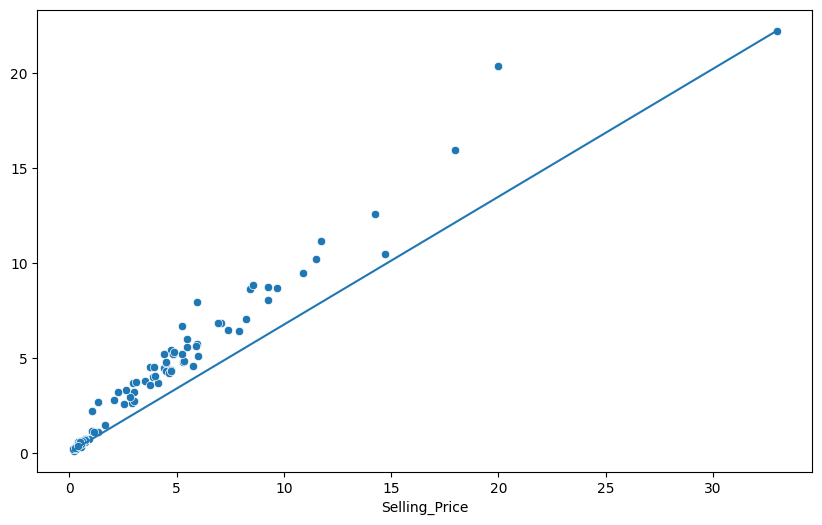

In [53]:
fig , axs = plt.subplots(1,1 , figsize = (10,6))

sns.scatterplot(ax = axs , x = y_test , y = y_pred)
sns.lineplot(ax = axs , x = [y_test.min() , y_test.max()] , y = [y_pred.min() , y_pred.max()])
plt.show()